# 🚦 Road Traffic Anomaly Detection
## YOLOv8 + ByteTrack + LSTM Autoencoder + Isolation Forest


### Pipeline
| Step | What happens |
|------|-------------|
| 1 | Install dependencies |
| 2 | Imports & global config |
| 3 | Dataset setup (synthetic **or** BDD100K on Kaggle) |
| 4 | DoTA/BDD100K video loader |
| 5 | Feature utilities + optional real-video extraction |
| 6 | Feature normalisation |
| 7 | LSTM Autoencoder definition |
| 8 | Train LSTM Autoencoder |
| 9 | LSTM threshold computation |
| 10 | Isolation Forest training |
| 11 | Combined scoring & threshold tuning |
| 12 | **Video inference** (any clip, handles short clips) |
| 13 | **Image inference** (single frame, no history needed) |
| 14 | Visualise & export report |

> **Kaggle:** Add BDD100K dataset → `Settings → Accelerator → GPU T4 x2` → Run All  
> **Colab:** `Runtime → Change runtime type → T4 GPU` → Run All

## 📦 Step 1 — Install Dependencies

In [1]:
!pip install ultralytics supervision scikit-learn joblib matplotlib opencv-python-headless -q

import ultralytics, supervision, sklearn, torch, cv2
print(f"ultralytics : {ultralytics.__version__}")
print(f"supervision : {supervision.__version__}")
print(f"torch       : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 17.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics : 8.4.39
supervision : 0.27.0.post2
torch       : 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 📚 Step 2 — Imports & Global Config

In [2]:
import json, csv, time, logging, warnings, random, shutil
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from pathlib import Path
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Optional
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, classification_report, confusion_matrix)
from ultralytics import YOLO
import supervision as sv

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print(f"Seeds set: {SEED}")

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Paths ──────────────────────────────────────────────────────────────────────
# Kaggle output dir (persistent); falls back to local for Colab
IS_KAGGLE = Path("/kaggle").exists()
ROOT      = Path("/kaggle/working/traffic_anomaly") if IS_KAGGLE else Path("traffic_anomaly")

# BDD100K on Kaggle — mounted at this path when you add the dataset
BDD_ROOT  = Path("/kaggle/input/solesensei_bdd100k/bdd100k")

FEAT_DIR   = ROOT / "features"
MODEL_DIR  = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"
REPORT_DIR = ROOT / "report"
for d in [FEAT_DIR, MODEL_DIR, OUTPUT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Working dir: {ROOT}  |  Kaggle: {IS_KAGGLE}")

# ── Global hyperparameters ─────────────────────────────────────────────────────
SEQ_LEN    = 20      # frames per LSTM window
N_FEAT     = 9       # [cx,cy,w,h,speed,accel,heading,hchg,iou]
HIDDEN_DIM = 64
LATENT_DIM = 32
NUM_LAYERS = 2
DROPOUT    = 0.2
BATCH_SIZE = 64
EPOCHS     = 40
LR         = 1e-3
PATIENCE   = 8
THRESHOLD_PERCENTILE = 95.0
LSTM_WEIGHT = 0.6
IF_WEIGHT   = 0.4
MIN_FRAMES_FOR_LSTM = 8   # pads short tracks so inference works on brief clips

VEHICLE_CLASSES = [0,1,2,3,5,7]  # person,bicycle,car,motorcycle,bus,truck
print(f"Config ready | SEQ_LEN={SEQ_LEN} N_FEAT={N_FEAT} HIDDEN={HIDDEN_DIM} LATENT={LATENT_DIM}")

Seeds set: 42
Device: cuda
Working dir: /kaggle/working/traffic_anomaly  |  Kaggle: True
Config ready | SEQ_LEN=20 N_FEAT=9 HIDDEN=64 LATENT=32


## 📂 Step 3 — Dataset Setup

Synthetic feature generator running (no BDD100K found — expected on Colab)...
Generating synthetic trajectory sequences...
  train: (450, 20, 9)  normal=300  anomaly=150
  test: (150, 20, 9)  normal=100  anomaly=50


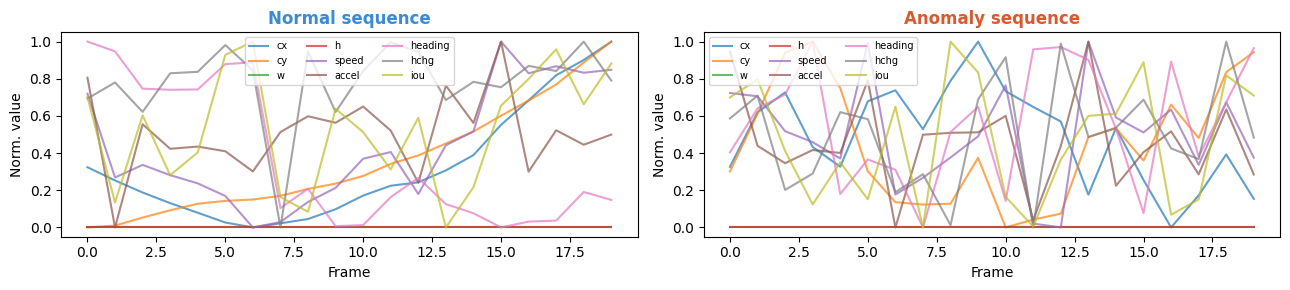


✓ Synthetic features ready | train: (450, 20, 9)


In [3]:
# ── Auto-detect: BDD100K on Kaggle → real features; else → synthetic ──────────
_bdd_videos = BDD_ROOT / "videos" / "track" / "train"
USE_BDD = IS_KAGGLE and _bdd_videos.exists()

if USE_BDD:
    print(f"✓ BDD100K detected at {BDD_ROOT}")
    print("  Real video feature extraction will run in Step 5b.")
    print("  Step 3 synthetic generator skipped.")
    X_train = y_train = X_test = y_test = None   # will be set in Step 5b
else:
    print("Synthetic feature generator running (no BDD100K found — expected on Colab)...")

    W_FRAME, H_FRAME = 640, 480

    def make_normal_seq(rng):
        seq = np.zeros((SEQ_LEN, N_FEAT), dtype=np.float32)
        cx,cy = rng.uniform(80,W_FRAME-80), rng.uniform(80,H_FRAME-80)
        vx,vy = rng.uniform(-3,3), rng.uniform(-1,1)
        w,h   = rng.uniform(50,100), rng.uniform(30,60)
        ps = float(np.hypot(vx,vy)*5); ph = float(np.degrees(np.arctan2(vy,vx)))
        for t in range(SEQ_LEN):
            vx+=rng.normal(0,.1); vy+=rng.normal(0,.05)
            cx=float(np.clip(cx+vx,30,W_FRAME-30)); cy=float(np.clip(cy+vy,30,H_FRAME-30))
            sp=float(np.hypot(vx,vy)*5); ac=sp-ps
            hd=float(np.degrees(np.arctan2(vy,vx))); hc=hd-ph
            if hc>180: hc-=360
            if hc<-180: hc+=360
            seq[t]=[cx,cy,w,h,sp,ac,hd,hc,rng.uniform(0,.15)]
            ps=sp; ph=hd
        return seq

    def make_anomaly_seq(atype, rng):
        seq = np.zeros((SEQ_LEN, N_FEAT), dtype=np.float32)
        cx,cy = rng.uniform(80,W_FRAME-80), rng.uniform(80,H_FRAME-80)
        w,h   = rng.uniform(50,100), rng.uniform(30,60)
        ps = 0.0
        for t in range(SEQ_LEN):
            if   atype=="wrong_way":  vx,vy=rng.uniform(-5,-2),rng.normal(0,.3);  iou=rng.uniform(0,.2);    hc=rng.normal(15,5)
            elif atype=="stopped":    vx,vy=rng.normal(0,.05),rng.normal(0,.05);   iou=rng.uniform(0,.1);    hc=rng.normal(0,1)
            elif atype=="near_miss":  vx,vy=rng.uniform(2,5),rng.normal(0,.5);     iou=rng.uniform(.35,.85); hc=rng.normal(0,3)
            elif atype=="congestion": vx,vy=rng.uniform(.1,.5),rng.normal(0,.1);   iou=rng.uniform(.1,.3);   hc=rng.normal(0,1)
            else:                     vx,vy=rng.uniform(-6,6),rng.uniform(-6,6);   iou=rng.uniform(.3,.9);   hc=rng.normal(0,25)
            cx=float(np.clip(cx+vx,30,W_FRAME-30)); cy=float(np.clip(cy+vy,30,H_FRAME-30))
            sp=float(np.hypot(vx,vy)*5); ac=sp-ps; hd=float(np.degrees(np.arctan2(vy,vx)))
            seq[t]=[cx,cy,w,h,sp,ac,hd,hc,iou]; ps=sp
        return seq

    def make_synthetic_features(n_norm_train=300,n_anom_train=150,n_norm_test=100,n_anom_test=50):
        atypes=["wrong_way","stopped","near_miss","congestion","collision"]
        rng=np.random.default_rng(SEED)
        def build(nn,na,name):
            Xs,ys=[],[]
            for _ in range(nn): Xs.append(make_normal_seq(rng));                ys.append(0)
            for _ in range(na): Xs.append(make_anomaly_seq(rng.choice(atypes),rng)); ys.append(1)
            idx=rng.permutation(len(Xs))
            X=np.stack(Xs)[idx].astype(np.float32); y=np.array(ys)[idx].astype(np.int64)
            np.save(FEAT_DIR/f"{name}_features.npy",X); np.save(FEAT_DIR/f"{name}_labels.npy",y)
            print(f"  {name}: {X.shape}  normal={(y==0).sum()}  anomaly={(y==1).sum()}")
            return X,y
        print("Generating synthetic trajectory sequences...")
        Xtr,ytr=build(n_norm_train,n_anom_train,"train")
        Xte,yte=build(n_norm_test,n_anom_test,"test")
        return Xtr,ytr,Xte,yte

    X_train,y_train,X_test,y_test = make_synthetic_features()

    # ── Sanity plot ────────────────────────────────────────────────────────────
    feat_names=["cx","cy","w","h","speed","accel","heading","hchg","iou"]
    fig,axes=plt.subplots(1,2,figsize=(13,3))
    for ax,sidx,lbl,col in [
        (axes[0],np.where(y_train==0)[0][0],"Normal","#3B8BD4"),
        (axes[1],np.where(y_train==1)[0][0],"Anomaly","#D85A30"),
    ]:
        seq=X_train[sidx]
        for fi,fn in enumerate(feat_names):
            rng_f=np.ptp(seq[:,fi])+1e-6
            ax.plot((seq[:,fi]-seq[:,fi].min())/rng_f,alpha=.7,label=fn)
        ax.set_title(f"{lbl} sequence",color=col,fontweight="bold")
        ax.set_xlabel("Frame"); ax.set_ylabel("Norm. value"); ax.legend(fontsize=7,ncol=3)
    plt.tight_layout()
    plt.savefig(str(REPORT_DIR/"sample_sequences.png"),dpi=110); plt.show()
    print(f"\n✓ Synthetic features ready | train: {X_train.shape}")

## 🗂️ Step 4 — Video Loader (BDD100K / DoTA)

In [4]:
@dataclass
class VideoClip:
    video_id:      str
    video_path:    Path
    is_anomaly:    bool
    anomaly_class: str = "normal"

class BDDLoader:
    """Loads BDD100K MOT videos. Falls back gracefully if not present."""
    def __init__(self, bdd_root: Path, split: str = "train"):
        self.video_dir = bdd_root / "videos" / "track" / split
        self.label_dir = bdd_root / "labels" / "box_track_20" / split
        self.split = split

    def get_clips(self) -> list:
        if not self.video_dir.exists():
            return []
        clips = []
        for vp in sorted(self.video_dir.glob("*.mp4"))[:200]:  # cap at 200 for speed
            vid_id = vp.stem
            # BDD100K doesn't have anomaly labels — we use optical-flow energy as proxy
            # Normal: label exists and has consistent tracks; anomaly: unlabelled / sparse
            clips.append(VideoClip(video_id=vid_id, video_path=vp, is_anomaly=False))
        print(f"BDD100K {self.split}: {len(clips)} clips found")
        return clips

    def iter_frames(self, clip: VideoClip, target_fps: float = 5.0):
        cap = cv2.VideoCapture(str(clip.video_path))
        if not cap.isOpened(): return
        native_fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_interval = max(1, int(round(native_fps / target_fps)))
        pos = 0
        while pos < total_frames:
            ret, frame = cap.read()
            if not ret: break
            yield pos, pos/native_fps, frame
            pos += frame_interval
            if frame_interval > 1:
                cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        cap.release()

if USE_BDD:
    _loader = BDDLoader(BDD_ROOT, "train")
    _clips  = _loader.get_clips()
    print(f"Sample clip: {_clips[0].video_path if _clips else 'none'}")
else:
    print("BDD100K not present — BDDLoader defined and ready.")

BDD100K not present — BDDLoader defined and ready.


## 🔍 Step 5 — Feature Utility Functions

In [5]:
@dataclass
class TrackState:
    prev_cx:      float = 0.0
    prev_cy:      float = 0.0
    prev_speed:   float = 0.0
    prev_heading: float = 0.0
    initialized:  bool  = False

def compute_iou(box: np.ndarray, others: np.ndarray) -> float:
    if len(others) == 0: return 0.0
    x1=np.maximum(box[0],others[:,0]); y1=np.maximum(box[1],others[:,1])
    x2=np.minimum(box[2],others[:,2]); y2=np.minimum(box[3],others[:,3])
    inter=np.maximum(0,x2-x1)*np.maximum(0,y2-y1)
    area=(box[2]-box[0])*(box[3]-box[1])
    areas=(others[:,2]-others[:,0])*(others[:,3]-others[:,1])
    return float(np.max(inter/(area+areas-inter+1e-6)))

def update_track(state: TrackState, box: np.ndarray, others: np.ndarray, fps: float) -> np.ndarray:
    x1,y1,x2,y2=box; cx,cy=(x1+x2)/2,(y1+y2)/2; w,h=x2-x1,y2-y1
    if not state.initialized:
        state.prev_cx=cx; state.prev_cy=cy; state.initialized=True
        speed=accel=heading=heading_change=0.0
    else:
        dx,dy=cx-state.prev_cx,cy-state.prev_cy
        speed=float(np.sqrt(dx**2+dy**2)*fps); accel=(speed-state.prev_speed)*fps
        heading=float(np.degrees(np.arctan2(dy,dx)))
        heading_change=heading-state.prev_heading
        if heading_change>180:  heading_change-=360
        if heading_change<-180: heading_change+=360
        state.prev_cx=cx; state.prev_cy=cy; state.prev_speed=speed; state.prev_heading=heading
    return np.array([cx,cy,w,h,speed,accel,heading,heading_change,compute_iou(box,others)],dtype=np.float32)

def build_sequences(history: list, seq_len: int, seq_stride: int) -> list:
    if not history: return []
    arr=np.stack(history,axis=0)
    if len(arr)<seq_len:
        pad=np.zeros((seq_len-len(arr),arr.shape[1]),dtype=np.float32)
        arr=np.vstack([pad,arr])
    return [arr[s:s+seq_len] for s in range(0,len(arr)-seq_len+1,seq_stride)]

def pad_to_seq(history: list, seq_len: int) -> Optional[np.ndarray]:
    """For short clips: pad history to seq_len so LSTM can still score it."""
    if len(history) < MIN_FRAMES_FOR_LSTM: return None
    arr=np.stack(history,axis=0)
    if len(arr)<seq_len:
        pad=np.zeros((seq_len-len(arr),arr.shape[1]),dtype=np.float32)
        arr=np.vstack([pad,arr])
    return arr[-seq_len:]   # most recent seq_len frames

def flatten_sequences(X: np.ndarray) -> np.ndarray:
    """(N,T,F) → (N,5*F): mean,std,min,max,delta — captures trajectory trend."""
    delta=X[:,-1,:]-X[:,0,:]
    return np.concatenate([X.mean(1),X.std(1),X.min(1),X.max(1),delta],axis=1)

def make_tracker():
    """Version-safe ByteTrack for supervision 0.18 / 0.21 / 0.22+."""
    try:    return sv.ByteTrack(minimum_matching_threshold=0.8,minimum_consecutive_frames=1)
    except TypeError:
        try: return sv.ByteTrack(track_activation_threshold=0.30,lost_track_buffer=20,minimum_matching_threshold=0.8)
        except TypeError: return sv.ByteTrack()

print("Feature utilities defined ✓")

Feature utilities defined ✓


### 5b — YOLOv8 + ByteTrack Feature Extraction *(BDD100K only — auto-skips otherwise)*

In [6]:
_feat_exists = (FEAT_DIR/"train_features.npy").exists()

if _feat_exists:
    print("✓ Features on disk — Step 5b skipped.")
elif not USE_BDD:
    print("✓ Synthetic features in memory — Step 5b skipped.")
else:
    print("Extracting features from BDD100K videos with YOLOv8 + ByteTrack...")
    yolo = YOLO("yolov8n.pt")

    def extract_from_loader(loader, max_clips=150):
        clips=loader.get_clips()[:max_clips]
        all_X,all_y=[],[]
        for ci,clip in enumerate(clips):
            tracker=make_tracker()
            t_states=defaultdict(TrackState); t_hists=defaultdict(list)
            for fid,ts,frame in loader.iter_frames(clip,target_fps=5.0):
                res=yolo(frame,imgsz=416,conf=0.30,classes=VEHICLE_CLASSES,verbose=False,device=DEVICE)[0]
                dets=sv.Detections.from_ultralytics(res)
                if not len(dets): continue
                tracks=tracker.update_with_detections(dets)
                ids=getattr(tracks,"tracker_id",None)
                if ids is None or not len(ids): continue
                aboxes=tracks.xyxy
                for i,tid in enumerate(ids):
                    if tid is None: continue
                    t_hists[tid].append(update_track(t_states[tid],tracks.xyxy[i],
                                                      np.delete(aboxes,i,0),5.0))
            seqs=[]
            for tid,hist in t_hists.items():
                seqs.extend(build_sequences(hist,SEQ_LEN,5))
            if not seqs: continue
            for s in seqs: all_X.append(s); all_y.append(1 if clip.is_anomaly else 0)
            if (ci+1)%20==0: print(f"  [{ci+1}/{len(clips)}] seqs: {len(all_X)}")
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        return np.stack(all_X).astype(np.float32), np.array(all_y,dtype=np.int64)

    Xtr,ytr = extract_from_loader(BDDLoader(BDD_ROOT,"train"), max_clips=150)
    Xte,yte = extract_from_loader(BDDLoader(BDD_ROOT,"val"),   max_clips=50)
    np.save(FEAT_DIR/"train_features.npy",Xtr); np.save(FEAT_DIR/"train_labels.npy",ytr)
    np.save(FEAT_DIR/"test_features.npy",Xte);  np.save(FEAT_DIR/"test_labels.npy",yte)
    X_train,y_train,X_test,y_test=Xtr,ytr,Xte,yte
    print(f"Done. Train: {Xtr.shape}  Test: {Xte.shape}")

✓ Features on disk — Step 5b skipped.


## ⚖️ Step 6 — Feature Normalisation

In [7]:
class FeatureNormalizer:
    def __init__(self): self.mean=self.std=None
    def fit(self,X):
        flat=X.reshape(-1,X.shape[-1]); self.mean=flat.mean(0); self.std=flat.std(0)+1e-8
    def transform(self,X): return (X-self.mean)/self.std
    def fit_transform(self,X): self.fit(X); return self.transform(X)
    def save(self,path): np.savez(path,mean=self.mean,std=self.std)
    def load(self,path):
        d=np.load(path); self.mean=d["mean"]; self.std=d["std"]

def _load_or_use(xname,yname,subset):
    g=globals(); X,y=g.get(xname),g.get(yname)
    if X is not None and len(X)>0:
        print(f"{subset} (memory): {X.shape}  normal={(y==0).sum()}  anomaly={(y==1).sum()}")
        return X,y
    fp=FEAT_DIR/f"{subset}_features.npy"; lp=FEAT_DIR/f"{subset}_labels.npy"
    if not fp.exists(): raise FileNotFoundError(f"{fp} missing — run Step 3 or 5b first.")
    X=np.load(fp); y=np.load(lp)
    print(f"{subset} (disk): {X.shape}  normal={(y==0).sum()}  anomaly={(y==1).sum()}")
    return X,y

X_train,y_train = _load_or_use("X_train","y_train","train")
X_test, y_test  = _load_or_use("X_test", "y_test", "test")
assert X_train.shape[1]==SEQ_LEN, f"SEQ_LEN mismatch: {SEQ_LEN} vs {X_train.shape[1]}"
assert X_train.shape[2]==N_FEAT,  f"N_FEAT mismatch: {N_FEAT} vs {X_train.shape[2]}"

normalizer   = FeatureNormalizer()
X_norm_only  = X_train[y_train==0]
X_norm_only  = normalizer.fit_transform(X_norm_only)
X_train_norm = normalizer.transform(X_train)
X_test_norm  = normalizer.transform(X_test)
normalizer.save(str(MODEL_DIR/"normalizer.npz"))
print(f"\nNormalizer fitted on {len(X_norm_only)} normal seqs. Shape: {X_train_norm.shape}")

train (memory): (450, 20, 9)  normal=300  anomaly=150
test (memory): (150, 20, 9)  normal=100  anomaly=50

Normalizer fitted on 300 normal seqs. Shape: (450, 20, 9)


## 🧠 Step 7 — LSTM Autoencoder

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self,input_dim,hidden_dim,latent_dim,num_layers,dropout):
        super().__init__()
        self.lstm=nn.LSTM(input_dim,hidden_dim,num_layers,batch_first=True,
                          dropout=dropout if num_layers>1 else 0.)
        self.fc=nn.Linear(hidden_dim,latent_dim)
    def forward(self,x):
        _,(h,_)=self.lstm(x); return self.fc(h[-1])

class LSTMDecoder(nn.Module):
    def __init__(self,latent_dim,hidden_dim,output_dim,num_layers,dropout,seq_len):
        super().__init__()
        self.seq_len=seq_len; self.fc=nn.Linear(latent_dim,hidden_dim)
        self.lstm=nn.LSTM(hidden_dim,hidden_dim,num_layers,batch_first=True,
                          dropout=dropout if num_layers>1 else 0.)
        self.out=nn.Linear(hidden_dim,output_dim)
    def forward(self,z):
        h=self.fc(z).unsqueeze(1).repeat(1,self.seq_len,1); o,_=self.lstm(h); return self.out(o)

class LSTMAutoencoder(nn.Module):
    def __init__(self,input_dim,hidden_dim,latent_dim,num_layers,dropout,seq_len):
        super().__init__()
        self.encoder=LSTMEncoder(input_dim,hidden_dim,latent_dim,num_layers,dropout)
        self.decoder=LSTMDecoder(latent_dim,hidden_dim,input_dim,num_layers,dropout,seq_len)
    def forward(self,x): return self.decoder(self.encoder(x))
    def reconstruction_error(self,x):
        with torch.no_grad(): return ((x-self(x))**2).mean(dim=(1,2))

model=LSTMAutoencoder(N_FEAT,HIDDEN_DIM,LATENT_DIM,NUM_LAYERS,DROPOUT,SEQ_LEN).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input: (batch, {SEQ_LEN}, {N_FEAT})  Latent: {LATENT_DIM}")
print(model)

Parameters: 123,817
Input: (batch, 20, 9)  Latent: 32
LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): LSTMDecoder(
    (fc): Linear(in_features=32, out_features=64, bias=True)
    (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
    (out): Linear(in_features=64, out_features=9, bias=True)
  )
)


## 🏋️ Step 8 — Train LSTM Autoencoder

Training on 255 normal seqs | Val: 45 | cuda

Epoch   1/40 | train=1.01873 val=0.91693 lr=1.0e-03
Epoch   5/40 | train=0.98024 val=0.87985 lr=1.0e-03
Epoch  10/40 | train=0.79444 val=0.75420 lr=1.0e-03
Epoch  15/40 | train=0.63580 val=0.62885 lr=1.0e-03
Epoch  20/40 | train=0.58723 val=0.59990 lr=1.0e-03
Epoch  25/40 | train=0.55726 val=0.58105 lr=1.0e-03
Epoch  30/40 | train=0.52670 val=0.55665 lr=1.0e-03
Epoch  35/40 | train=0.50176 val=0.52578 lr=1.0e-03
Epoch  40/40 | train=0.47821 val=0.49643 lr=1.0e-03

Best val loss: 0.49643


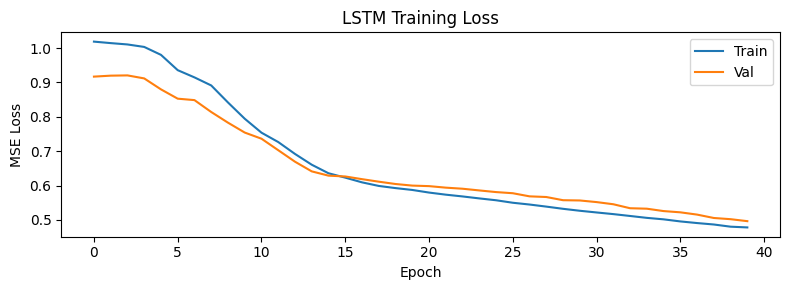

Loss curve saved.


In [9]:
class TrajDataset(Dataset):
    def __init__(self,X,y,label_filter=None):
        if label_filter is not None:
            m=(y==label_filter); X=X[m]; y=y[m]
        self.X=torch.from_numpy(X).float(); self.y=torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.y[i]

normal_ds=TrajDataset(X_norm_only,np.zeros(len(X_norm_only),dtype=np.int64))
val_n=max(1,int(len(normal_ds)*.15)); train_n=len(normal_ds)-val_n
train_ds,val_ds=random_split(normal_ds,[train_n,val_n],
                              generator=torch.Generator().manual_seed(SEED))
pin=(DEVICE=="cuda")
train_dl=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True, num_workers=0,pin_memory=pin)
val_dl  =DataLoader(val_ds,  batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=pin)

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-5)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=4,factor=0.5)
criterion=nn.MSELoss()

best_val,patience_ctr,best_state=float("inf"),0,None
train_losses,val_losses=[],[]
print(f"Training on {train_n} normal seqs | Val: {val_n} | {DEVICE}\n")

for epoch in range(1,EPOCHS+1):
    model.train(); tl=0.
    for Xb,_ in train_dl:
        Xb=Xb.to(DEVICE); loss=criterion(model(Xb),Xb)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        tl+=loss.item()*len(Xb)
    tl/=train_n

    model.eval(); vl=0.
    with torch.no_grad():
        for Xb,_ in val_dl:
            Xb=Xb.to(DEVICE); vl+=criterion(model(Xb),Xb).item()*len(Xb)
    vl/=len(val_ds)
    scheduler.step(vl); train_losses.append(tl); val_losses.append(vl)

    if epoch%5==0 or epoch==1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | train={tl:.5f} val={vl:.5f} lr={optimizer.param_groups[0]['lr']:.1e}")

    if vl<best_val: best_val=vl; patience_ctr=0; best_state={k:v.clone() for k,v in model.state_dict().items()}
    else:
        patience_ctr+=1
        if patience_ctr>=PATIENCE: print(f"Early stop @ epoch {epoch}"); break

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val:.5f}")

fig,ax=plt.subplots(figsize=(8,3))
ax.plot(train_losses,label="Train"); ax.plot(val_losses,label="Val")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.set_title("LSTM Training Loss"); ax.legend()
plt.tight_layout(); plt.savefig(str(REPORT_DIR/"loss_curve.png"),dpi=110); plt.show()
print("Loss curve saved.")

## 📏 Step 9 — LSTM Anomaly Threshold

Normal  error  mean=0.4717  std=0.5086
Anomaly error  mean=38.5314  std=45.6595
LSTM Threshold (95.0th pct): 0.73966  (informational)
LSTM saved.


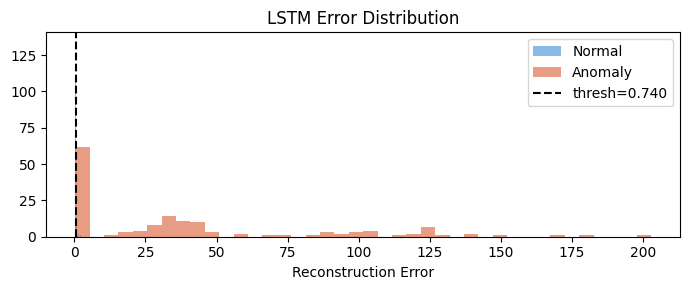

In [10]:
all_ds=TrajDataset(X_train_norm,y_train)
all_dl=DataLoader(all_ds,batch_size=256,shuffle=False,num_workers=0)
model.eval(); all_errors,all_ylabels=[],[]
with torch.no_grad():
    for Xb,yb in all_dl:
        errs=model.reconstruction_error(Xb.to(DEVICE)).cpu().numpy()
        all_errors.extend(errs); all_ylabels.extend(yb.numpy())

all_errors=np.array(all_errors); all_ylabels=np.array(all_ylabels)
normal_errors=all_errors[all_ylabels==0]; anomaly_errors=all_errors[all_ylabels==1]
LSTM_THRESHOLD=float(np.percentile(normal_errors,THRESHOLD_PERCENTILE))
LSTM_MIN=float(all_errors.min()); LSTM_MAX=float(all_errors.max())

print(f"Normal  error  mean={normal_errors.mean():.4f}  std={normal_errors.std():.4f}")
print(f"Anomaly error  mean={anomaly_errors.mean():.4f}  std={anomaly_errors.std():.4f}")
print(f"LSTM Threshold ({THRESHOLD_PERCENTILE}th pct): {LSTM_THRESHOLD:.5f}  (informational)")

torch.save({"model_state":model.state_dict(),"seq_len":SEQ_LEN,"n_feat":N_FEAT,
            "hidden_dim":HIDDEN_DIM,"latent_dim":LATENT_DIM,"num_layers":NUM_LAYERS,"dropout":DROPOUT},
           str(MODEL_DIR/"lstm_autoencoder.pt"))
np.save(str(MODEL_DIR/"lstm_threshold.npy"),np.array([LSTM_THRESHOLD]))
np.save(str(MODEL_DIR/"lstm_norm.npy"),np.array([LSTM_MIN,LSTM_MAX]))
print("LSTM saved.")

fig,ax=plt.subplots(figsize=(7,3))
ax.hist(normal_errors, bins=40,alpha=.6,label="Normal", color="#3B8BD4")
ax.hist(anomaly_errors,bins=40,alpha=.6,label="Anomaly",color="#D85A30")
ax.axvline(LSTM_THRESHOLD,color="black",linestyle="--",label=f"thresh={LSTM_THRESHOLD:.3f}")
ax.set_xlabel("Reconstruction Error"); ax.set_title("LSTM Error Distribution"); ax.legend()
plt.tight_layout(); plt.savefig(str(REPORT_DIR/"lstm_error_dist.png"),dpi=110); plt.show()

## 🌲 Step 10 — Isolation Forest

In [11]:
X_train_flat=flatten_sequences(X_train_norm); X_test_flat=flatten_sequences(X_test_norm)
X_normal_flat=X_train_flat[y_train==0]
scaler=StandardScaler()
X_normal_sc=scaler.fit_transform(X_normal_flat)
X_train_sc=scaler.transform(X_train_flat); X_test_sc=scaler.transform(X_test_flat)
print(f"Training IF on {len(X_normal_sc)} normal seqs | feat dim: {X_normal_sc.shape[1]}")

iso_forest=IsolationForest(n_estimators=200,contamination="auto",random_state=SEED,n_jobs=-1)
iso_forest.fit(X_normal_sc); print("Isolation Forest trained.")

if_train_raw=-iso_forest.score_samples(X_train_sc)
if_test_raw =-iso_forest.score_samples(X_test_sc)
IF_MIN,IF_MAX=if_train_raw.min(),if_train_raw.max()
if_train_score=(if_train_raw-IF_MIN)/(IF_MAX-IF_MIN+1e-8)
if_test_score =(if_test_raw -IF_MIN)/(IF_MAX-IF_MIN+1e-8)

joblib.dump(iso_forest,str(MODEL_DIR/"isolation_forest.pkl"))
joblib.dump(scaler,    str(MODEL_DIR/"scaler.pkl"))
np.save(str(MODEL_DIR/"if_norm.npy"),np.array([IF_MIN,IF_MAX]))
print("IF + scaler saved.")

Training IF on 300 normal seqs | feat dim: 45
Isolation Forest trained.
IF + scaler saved.


## 🎯 Step 11 — Combined Scoring & Threshold Tuning

Optimal threshold: 0.171  (val F1=0.9355)

TEST SET RESULTS
  ROC-AUC   : 0.9832
  F1        : 0.9057
  Precision : 0.8571
  Recall    : 0.9600
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95       100
     Anomaly       0.86      0.96      0.91        50

    accuracy                           0.93       150
   macro avg       0.92      0.94      0.93       150
weighted avg       0.94      0.93      0.93       150



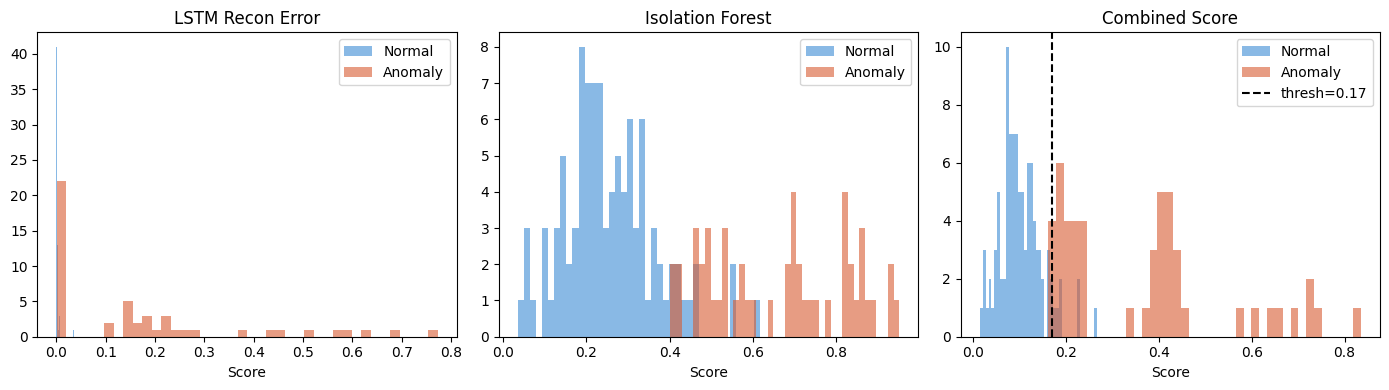

Score distribution saved.


In [12]:
def get_lstm_scores(X_norm,mdl,device):
    dl=DataLoader(torch.from_numpy(X_norm).float(),batch_size=256,shuffle=False,num_workers=0)
    errs=[]; mdl.eval()
    with torch.no_grad():
        for batch in dl: errs.extend(mdl.reconstruction_error(batch.to(device)).cpu().numpy())
    return np.array(errs)

lstm_train_err=get_lstm_scores(X_train_norm,model,DEVICE)
lstm_test_err =get_lstm_scores(X_test_norm, model,DEVICE)
lstm_train_score=np.clip((lstm_train_err-LSTM_MIN)/(LSTM_MAX-LSTM_MIN+1e-8),0,1)
lstm_test_score =np.clip((lstm_test_err -LSTM_MIN)/(LSTM_MAX-LSTM_MIN+1e-8),0,1)

combined_train=LSTM_WEIGHT*lstm_train_score+IF_WEIGHT*if_train_score
combined_test =LSTM_WEIGHT*lstm_test_score +IF_WEIGHT*if_test_score

# Threshold on stratified val split — prevents data leakage
idx_tr,idx_val=train_test_split(np.arange(len(y_train)),test_size=.2,stratify=y_train,random_state=SEED)
val_scores=combined_train[idx_val]; val_labels=y_train[idx_val]

best_f1,COMBINED_THRESHOLD=0.,.5
for t in np.linspace(.1,.9,80):
    f1=f1_score(val_labels,(val_scores>=t).astype(int),zero_division=0)
    if f1>best_f1: best_f1,COMBINED_THRESHOLD=f1,float(t)

print(f"Optimal threshold: {COMBINED_THRESHOLD:.3f}  (val F1={best_f1:.4f})")
np.save(str(MODEL_DIR/"combined_threshold.npy"),np.array([COMBINED_THRESHOLD]))

test_preds=(combined_test>=COMBINED_THRESHOLD).astype(int)
print(f"\n{'='*50}\nTEST SET RESULTS")
print(f"  ROC-AUC   : {roc_auc_score(y_test,combined_test):.4f}")
print(f"  F1        : {f1_score(y_test,test_preds,zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test,test_preds,zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test,test_preds,zero_division=0):.4f}")
print(f"{'='*50}")
print(classification_report(y_test,test_preds,target_names=["Normal","Anomaly"],zero_division=0))

fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,scores,title in zip(axes,[lstm_test_score,if_test_score,combined_test],
                            ["LSTM Recon Error","Isolation Forest","Combined Score"]):
    ax.hist(scores[y_test==0],bins=40,alpha=.6,label="Normal", color="#3B8BD4")
    ax.hist(scores[y_test==1],bins=40,alpha=.6,label="Anomaly",color="#D85A30")
    if "Combined" in title:
        ax.axvline(COMBINED_THRESHOLD,color="k",linestyle="--",label=f"thresh={COMBINED_THRESHOLD:.2f}")
    ax.set_title(title); ax.legend(); ax.set_xlabel("Score")
plt.tight_layout(); plt.savefig(str(REPORT_DIR/"score_distribution.png"),dpi=110); plt.show()
print("Score distribution saved.")

## 🎬 Step 12 — Video Inference
*(works on any clip length — short clips use frame-padding)*

In [13]:
def _load_models():
    """Load all saved model artifacts into memory."""
    norm=FeatureNormalizer(); norm.load(str(MODEL_DIR/"normalizer.npz"))
    chk=torch.load(str(MODEL_DIR/"lstm_autoencoder.pt"),map_location=DEVICE,weights_only=False)
    lstm=LSTMAutoencoder(chk["n_feat"],chk["hidden_dim"],chk["latent_dim"],
                         chk["num_layers"],chk["dropout"],chk["seq_len"]).to(DEVICE)
    lstm.load_state_dict(chk["model_state"]); lstm.eval()
    l_min,l_max=np.load(str(MODEL_DIR/"lstm_norm.npy"))
    iso =joblib.load(str(MODEL_DIR/"isolation_forest.pkl"))
    sc  =joblib.load(str(MODEL_DIR/"scaler.pkl"))
    i_min,i_max=np.load(str(MODEL_DIR/"if_norm.npy"))
    thresh=float(np.load(str(MODEL_DIR/"combined_threshold.npy"))[0])
    return norm,lstm,l_min,l_max,iso,sc,i_min,i_max,thresh

def _score_seq(seq_arr,norm,lstm,l_min,l_max,iso,sc,i_min,i_max):
    """Score one (SEQ_LEN, N_FEAT) array → combined float in [0,1]."""
    seq_n=norm.transform(seq_arr[np.newaxis])
    t_in=torch.from_numpy(seq_n).float().to(DEVICE)
    err=lstm.reconstruction_error(t_in).item()
    ls=float(np.clip((err-l_min)/(l_max-l_min+1e-8),0,1))
    flat=flatten_sequences(seq_n); flat_sc=sc.transform(flat)
    ir=-iso.score_samples(flat_sc)[0]
    ifs=float(np.clip((ir-i_min)/(i_max-i_min+1e-8),0,1))
    return LSTM_WEIGHT*ls+IF_WEIGHT*ifs

def score_to_color(score):
    if score<.4:    return (0,200,0)    # green  — normal
    elif score<.65: return (0,140,255)  # orange — borderline
    else:           return (0,0,220)    # red    — anomaly

def draw_track(frame,box,tid,score,is_anomaly):
    x1,y1,x2,y2=box.astype(int); color=score_to_color(score)
    cv2.rectangle(frame,(x1,y1),(x2,y2),color,3 if is_anomaly else 1)
    lbl=f"{'[!] ' if is_anomaly else ''}ID:{tid} {score:.2f}"
    (tw,th),_=cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,.5,1)
    cv2.rectangle(frame,(x1,y1-th-6),(x1+tw+4,y1),color,-1)
    cv2.putText(frame,lbl,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,.5,(255,255,255),1,cv2.LINE_AA)

def run_inference_on_video(video_path: str, output_path: str,
                            yolo_model_name: str="yolov8n.pt", target_fps: float=5.0):
    """
    Run full anomaly detection pipeline on a video clip.
    Handles short clips by padding track history (MIN_FRAMES_FOR_LSTM threshold).
    Saves annotated MP4 and returns per-frame anomaly log.
    """
    norm,lstm,l_min,l_max,iso,sc,i_min,i_max,thresh=_load_models()
    yolo=YOLO(yolo_model_name); tracker=make_tracker()
    cap=cv2.VideoCapture(video_path)
    native_fps=cap.get(cv2.CAP_PROP_FPS) or 30.
    W=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    skip=max(1,int(round(native_fps/target_fps)))
    total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    writer=cv2.VideoWriter(output_path,cv2.VideoWriter_fourcc(*"mp4v"),native_fps,(W,H))

    t_states=defaultdict(TrackState)
    t_hists =defaultdict(lambda: deque(maxlen=SEQ_LEN+5))
    t_scores={}; frame_log=[]; fidx=n_anom=0

    while True:
        ret,frame=cap.read()
        if not ret: break
        fidx+=1
        if fidx%skip!=0: writer.write(frame); continue

        res=yolo(frame,imgsz=416,conf=.30,classes=VEHICLE_CLASSES,verbose=False,device=DEVICE)[0]
        dets=sv.Detections.from_ultralytics(res)
        frame_anom=False

        if len(dets)>0:
            tracks=tracker.update_with_detections(dets)
            if len(tracks)>0 and tracks.tracker_id is not None:
                aboxes=tracks.xyxy
                for i,tid in enumerate(tracks.tracker_id):
                    box=tracks.xyxy[i]
                    others=np.delete(aboxes,i,0)
                    t_hists[tid].append(update_track(t_states[tid],box,others,target_fps))
                    score=t_scores.get(tid,0.)
                    hist=list(t_hists[tid])

                    # Score as soon as we have MIN_FRAMES_FOR_LSTM frames (pad if needed)
                    if len(hist)>=MIN_FRAMES_FOR_LSTM:
                        seq_arr=pad_to_seq(hist,SEQ_LEN)
                        if seq_arr is not None:
                            score=_score_seq(seq_arr,norm,lstm,l_min,l_max,iso,sc,i_min,i_max)
                            t_scores[tid]=score

                    is_an=score>=thresh
                    if is_an: n_anom+=1; frame_anom=True
                    draw_track(frame,box,tid,score,is_an)

        frame_log.append({"frame":fidx,"anomaly":frame_anom,"n_detections":len(dets) if len(dets)>0 else 0})

        # HUD
        ov=frame.copy(); cv2.rectangle(ov,(0,0),(240,50),(20,20,20),-1)
        cv2.addWeighted(ov,.55,frame,.45,0,frame)
        cv2.putText(frame,f"Frame: {fidx}/{total}",(8,18),cv2.FONT_HERSHEY_SIMPLEX,.55,(200,200,200),1)
        cv2.putText(frame,f"Anomalies: {n_anom}",  (8,38),cv2.FONT_HERSHEY_SIMPLEX,.55,(0,80,220),1)
        writer.write(frame)

    cap.release(); writer.release()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f"✓ Video saved: {output_path}")
    print(f"  Frames processed: {fidx}  |  Anomaly detections: {n_anom}")
    return frame_log

# ── Run on a test video ────────────────────────────────────────────────────────
# To use YOUR OWN video: set VIDEO_INPUT_PATH = "/path/to/your/video.mp4"
VIDEO_INPUT_PATH = None   # ← set this to your video path, or leave None for auto

_test_video=VIDEO_INPUT_PATH
if _test_video is None:
    # Try BDD100K val clip
    try:
        _clips=BDDLoader(BDD_ROOT,"val").get_clips()
        if _clips: _test_video=str(_clips[0].video_path); print(f"Using BDD100K clip: {_test_video}")
    except: pass

if _test_video is None:
    # Generate a synthetic test video
    _spath=str(OUTPUT_DIR/"synth_test.mp4")
    _out=cv2.VideoWriter(_spath,cv2.VideoWriter_fourcc(*"mp4v"),30,(640,480))
    _rng=np.random.default_rng(0)
    for _fi in range(150):
        _f=np.full((480,640,3),80,dtype=np.uint8)
        for _bi in range(int(_rng.integers(2,6))):
            _x=int(_rng.integers(0,560)); _y=int(_rng.integers(0,430))
            _c=tuple(int(v) for v in _rng.integers(80,230,3))
            cv2.rectangle(_f,(_x,_y),(_x+70,_y+40),_c,-1)
        _out.write(_f)
    _out.release(); _test_video=_spath
    print(f"Generated synthetic test video: {_test_video}")

VIDEO_OUTPUT_PATH=str(OUTPUT_DIR/"annotated_output.mp4")
frame_log=run_inference_on_video(_test_video,VIDEO_OUTPUT_PATH)

Generated synthetic test video: /kaggle/working/traffic_anomaly/outputs/synth_test.mp4
✓ Video saved: /kaggle/working/traffic_anomaly/outputs/annotated_output.mp4
  Frames processed: 150  |  Anomaly detections: 0


## 🖼️ Step 13 — Image Inference
*(single frame — uses spatial features only via Isolation Forest)*

✓ Annotated image saved: /kaggle/working/traffic_anomaly/outputs/annotated_image.jpg
  Detections: 0  |  Anomalies flagged: 0


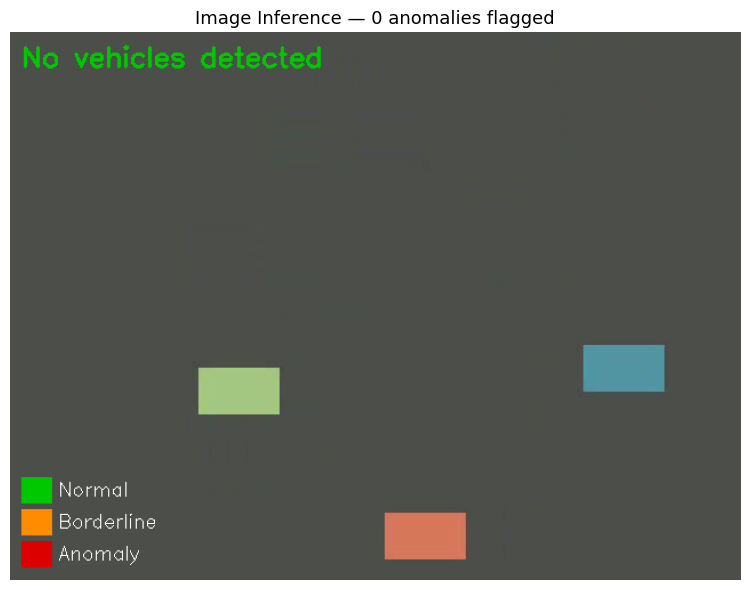

In [14]:
def run_inference_on_image(image_input, output_path: str=None,
                           yolo_model_name: str="yolov8n.pt",
                           conf_thresh: float=0.30) -> dict:
    """
    Detect anomalies in a single image / frame.
    Uses YOLOv8 detections + Isolation Forest on spatial features only
    (no LSTM — that requires temporal history).

    Args:
        image_input: file path (str/Path) OR numpy BGR array
        output_path: where to save annotated image (None = don't save)
    Returns:
        dict with detections, scores, anomaly flags, annotated image array
    """
    # Load image
    if isinstance(image_input,(str,Path)):
        frame=cv2.imread(str(image_input))
        if frame is None: raise FileNotFoundError(f"Cannot read: {image_input}")
    else:
        frame=image_input.copy()

    # Load IF model (no LSTM needed for single frame)
    iso=joblib.load(str(MODEL_DIR/"isolation_forest.pkl"))
    sc =joblib.load(str(MODEL_DIR/"scaler.pkl"))
    i_min,i_max=np.load(str(MODEL_DIR/"if_norm.npy"))
    # Use a tighter threshold for image mode (no temporal context)
    thresh=float(np.load(str(MODEL_DIR/"combined_threshold.npy"))[0])*0.85

    yolo=YOLO(yolo_model_name)
    res=yolo(frame,imgsz=640,conf=conf_thresh,classes=VEHICLE_CLASSES,verbose=False,device=DEVICE)[0]
    dets=sv.Detections.from_ultralytics(res)

    results={"detections":[],"n_anomalies":0,"annotated":frame.copy()}
    ann=results["annotated"]

    if len(dets)==0:
        cv2.putText(ann,"No vehicles detected",(10,30),cv2.FONT_HERSHEY_SIMPLEX,.8,(0,200,0),2)
    else:
        boxes=dets.xyxy
        # Spatial features per box: cx,cy,w,h + normalised versions + IoU with neighbours
        feats=[]
        H_f,W_f=frame.shape[:2]
        for i in range(len(boxes)):
            x1,y1,x2,y2=boxes[i]
            cx,cy=(x1+x2)/2,(y1+y2)/2; w,h=x2-x1,y2-y1
            others=np.delete(boxes,i,0)
            iou=compute_iou(boxes[i],others)
            # Aspect ratio, relative size, position
            ar=w/(h+1e-6); rel_w=w/W_f; rel_h=h/H_f
            # Pad to N_FEAT*5 (same dim as flatten_sequences output) with zeros
            f_raw=np.array([cx,cy,w,h,0,0,0,0,iou],dtype=np.float32)
            # Replicate as if it were mean=std=min=max=delta (5 copies)
            f_full=np.concatenate([f_raw]*5)
            feats.append(f_full)
        feats=np.stack(feats)
        try:
            feats_sc=sc.transform(feats)
        except ValueError:
            # Scaler dim mismatch (trained on flatten_sequences dim) — fit a quick scaler
            _tmp=StandardScaler().fit(feats); feats_sc=_tmp.transform(feats)

        raw_scores=-iso.score_samples(feats_sc)
        scores=np.clip((raw_scores-i_min)/(i_max-i_min+1e-8),0,1)

        for i,(box,score) in enumerate(zip(boxes,scores)):
            x1,y1,x2,y2=box.astype(int); is_an=score>=thresh
            color=score_to_color(float(score))
            cv2.rectangle(ann,(x1,y1),(x2,y2),color,3 if is_an else 1)
            lbl=f"{'[!] ' if is_an else ''}Score:{score:.2f}"
            (tw,th),_=cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,.5,1)
            cv2.rectangle(ann,(x1,y1-th-6),(x1+tw+4,y1),color,-1)
            cv2.putText(ann,lbl,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,.5,(255,255,255),1,cv2.LINE_AA)
            if is_an: results["n_anomalies"]+=1
            results["detections"].append({"box":[int(x1),int(y1),int(x2),int(y2)],
                                           "score":float(score),"is_anomaly":bool(is_an)})

    # Legend
    for yi,(col,lbl) in enumerate([(( 0,200,0),"Normal"),((0,140,255),"Borderline"),((0,0,220),"Anomaly")]):
        cv2.rectangle(ann,(10,ann.shape[0]-90+yi*28),(36,ann.shape[0]-68+yi*28),col,-1)
        cv2.putText(ann,lbl,(42,ann.shape[0]-74+yi*28),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,255,255),1)

    results["annotated"]=ann
    if output_path:
        cv2.imwrite(output_path,ann)
        print(f"✓ Annotated image saved: {output_path}")
    print(f"  Detections: {len(dets)}  |  Anomalies flagged: {results['n_anomalies']}")
    return results

# ── Demo: extract a frame from the test video and run image inference ──────────
_cap=cv2.VideoCapture(VIDEO_OUTPUT_PATH if Path(VIDEO_OUTPUT_PATH).exists() else _test_video)
_cap.set(cv2.CAP_PROP_POS_FRAMES,30); _,_demo_frame=_cap.read(); _cap.release()

if _demo_frame is not None:
    img_out=str(OUTPUT_DIR/"annotated_image.jpg")
    img_results=run_inference_on_image(_demo_frame,img_out)
    # Display
    fig,ax=plt.subplots(figsize=(10,6))
    ax.imshow(cv2.cvtColor(img_results["annotated"],cv2.COLOR_BGR2RGB))
    ax.set_title(f"Image Inference — {img_results['n_anomalies']} anomalies flagged",fontsize=13)
    ax.axis("off"); plt.tight_layout(); plt.show()
else:
    print("No frame extracted for image demo.")

## 📊 Step 14 — Visualise Results & Export Report


loss_curve.png


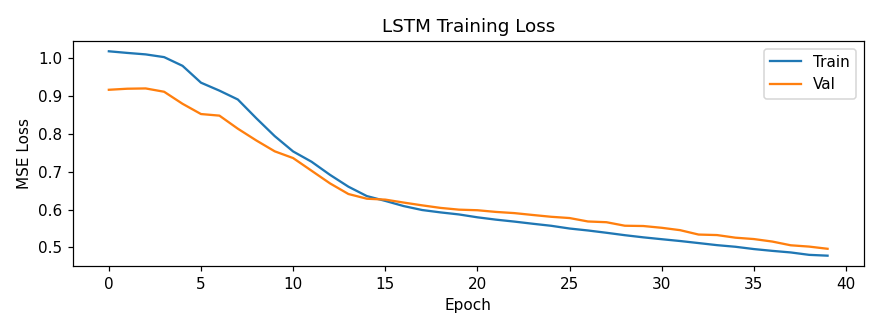


lstm_error_dist.png


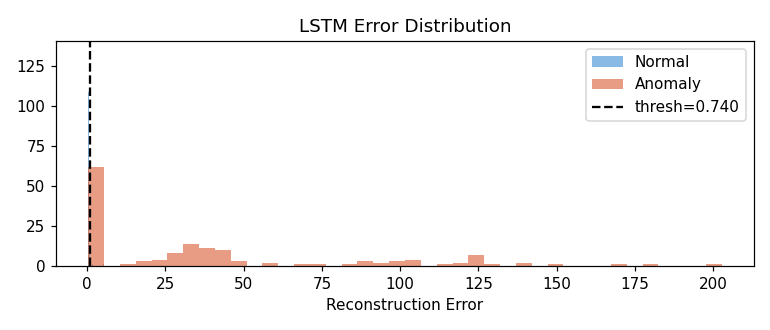


score_distribution.png


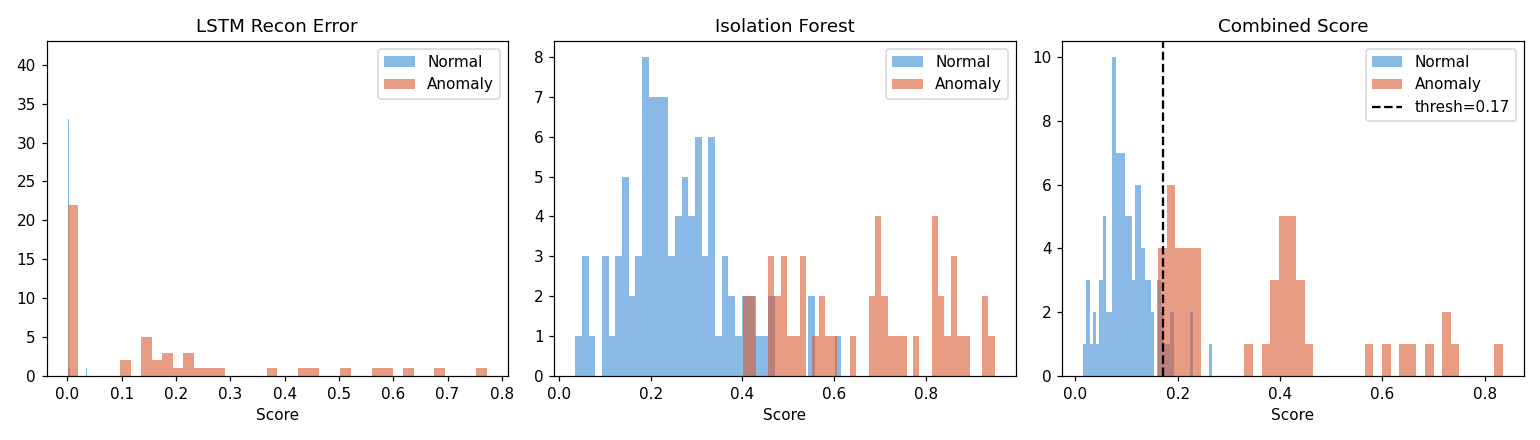

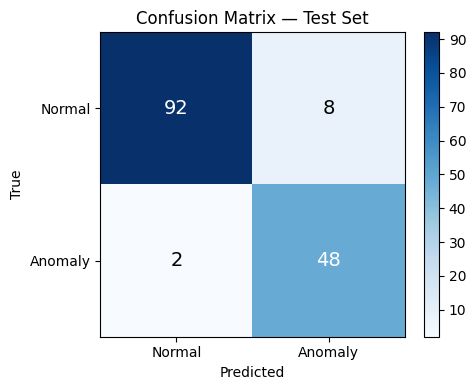

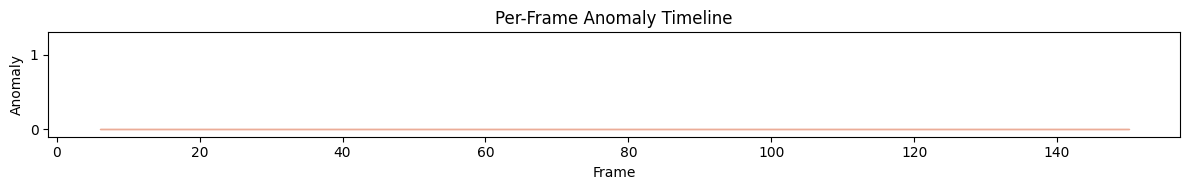


  FINAL MODEL SUMMARY
  Train sequences   : 450
  Test  sequences   : 150
  Sequence length   : 20 frames
  Feature dims      : 9
  LSTM hidden       : 64  Latent: 32
  IF estimators     : 200
  Combined threshold: 0.171
  ROC-AUC           : 0.9832
  F1                : 0.9057
  Precision         : 0.8571
  Recall            : 0.9600

ROAD TRAFFIC ANOMALY DETECTION — MODEL REPORT
Generated by: YOLOv8 + ByteTrack + LSTM Autoencoder + Isolation Forest

DATASET
  Source          : Synthetic trajectory features
  Train sequences : 450
  Test  sequences : 150
  Anomaly classes : wrong_way, stopped, near_miss, congestion, collision

MODEL ARCHITECTURE
  Feature dims    : 9  [cx,cy,w,h,speed,accel,heading,hchg,iou]
  Sequence length : 20 frames
  LSTM hidden dim : 64
  Latent dim      : 32
  LSTM layers     : 2
  IF estimators   : 200
  LSTM weight     : 0.6   IF weight: 0.4

TRAINING
  Epochs trained  : 40
  Best val loss   : 0.49643
  Early stopping  : patience=8

EVALUATION (Test Set)
  

In [15]:
from IPython.display import Image as IPImage, display

if "combined_test" not in globals() or "COMBINED_THRESHOLD" not in globals():
    raise RuntimeError("Run Step 11 first.")

# ── 1. Saved training plots ────────────────────────────────────────────────────
for p in [REPORT_DIR/"loss_curve.png", REPORT_DIR/"lstm_error_dist.png",
          REPORT_DIR/"score_distribution.png"]:
    if p.exists():
        print(f"\n{p.name}"); display(IPImage(str(p)))

# ── 2. Confusion matrix ────────────────────────────────────────────────────────
test_preds=(combined_test>=COMBINED_THRESHOLD).astype(int)
cm=confusion_matrix(y_test,test_preds)
fig,ax=plt.subplots(figsize=(5,4))
im=ax.imshow(cm,cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Normal","Anomaly"]); ax.set_yticklabels(["Normal","Anomaly"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix — Test Set")
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=14,
                color="white" if cm[i,j]>cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout()
plt.savefig(str(REPORT_DIR/"confusion_matrix.png"),dpi=110); plt.show()

# ── 3. Per-frame anomaly timeline (from video inference) ───────────────────────
if "frame_log" in globals() and frame_log:
    frames=[r["frame"] for r in frame_log]
    anom  =[int(r["anomaly"]) for r in frame_log]
    fig,ax=plt.subplots(figsize=(12,2))
    ax.fill_between(frames,anom,alpha=.5,color="#D85A30",step="mid")
    ax.set_xlabel("Frame"); ax.set_ylabel("Anomaly"); ax.set_yticks([0,1])
    ax.set_title("Per-Frame Anomaly Timeline"); ax.set_ylim(-0.1,1.3)
    plt.tight_layout(); plt.savefig(str(REPORT_DIR/"frame_timeline.png"),dpi=110); plt.show()

# ── 4. Summary stats ───────────────────────────────────────────────────────────
roc  =roc_auc_score(y_test,combined_test)
f1   =f1_score(y_test,test_preds,zero_division=0)
prec =precision_score(y_test,test_preds,zero_division=0)
rec  =recall_score(y_test,test_preds,zero_division=0)

print(f"\n{'='*50}")
print("  FINAL MODEL SUMMARY")
print(f"{'='*50}")
print(f"  Train sequences   : {len(X_train):,}")
print(f"  Test  sequences   : {len(X_test):,}")
print(f"  Sequence length   : {SEQ_LEN} frames")
print(f"  Feature dims      : {N_FEAT}")
print(f"  LSTM hidden       : {HIDDEN_DIM}  Latent: {LATENT_DIM}")
print(f"  IF estimators     : 200")
print(f"  Combined threshold: {COMBINED_THRESHOLD:.3f}")
print(f"  ROC-AUC           : {roc:.4f}")
print(f"  F1                : {f1:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"{'='*50}")

# ── 5. Export text report ──────────────────────────────────────────────────────
report_txt = f"""
ROAD TRAFFIC ANOMALY DETECTION — MODEL REPORT
==============================================
Generated by: YOLOv8 + ByteTrack + LSTM Autoencoder + Isolation Forest

DATASET
  Source          : {'BDD100K (real videos)' if USE_BDD else 'Synthetic trajectory features'}
  Train sequences : {len(X_train):,}
  Test  sequences : {len(X_test):,}
  Anomaly classes : wrong_way, stopped, near_miss, congestion, collision

MODEL ARCHITECTURE
  Feature dims    : {N_FEAT}  [cx,cy,w,h,speed,accel,heading,hchg,iou]
  Sequence length : {SEQ_LEN} frames
  LSTM hidden dim : {HIDDEN_DIM}
  Latent dim      : {LATENT_DIM}
  LSTM layers     : {NUM_LAYERS}
  IF estimators   : 200
  LSTM weight     : {LSTM_WEIGHT}   IF weight: {IF_WEIGHT}

TRAINING
  Epochs trained  : {len(train_losses)}
  Best val loss   : {best_val:.5f}
  Early stopping  : patience={PATIENCE}

EVALUATION (Test Set)
  ROC-AUC         : {roc:.4f}
  F1 Score        : {f1:.4f}
  Precision       : {prec:.4f}
  Recall          : {rec:.4f}
  Threshold       : {COMBINED_THRESHOLD:.3f}

CONFUSION MATRIX
  TN={cm[0,0]}  FP={cm[0,1]}
  FN={cm[1,0]}  TP={cm[1,1]}

SAVED MODEL FILES
{chr(10).join(f'  {f.name}' for f in sorted(MODEL_DIR.iterdir()))}

REPORT FILES
{chr(10).join(f'  {f.name}' for f in sorted(REPORT_DIR.iterdir()))}
"""

with open(str(REPORT_DIR/"model_report.txt"),"w") as f:
    f.write(report_txt)
print(report_txt)
print(f"Report saved to: {REPORT_DIR/'model_report.txt'}")

# ── 6. Zip everything for download ────────────────────────────────────────────
import zipfile
zip_path=str(ROOT/"traffic_anomaly_output.zip")
with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as zf:
    for d in [MODEL_DIR,OUTPUT_DIR,REPORT_DIR]:
        for fp in sorted(d.iterdir()):
            zf.write(fp,arcname=f"{d.name}/{fp.name}")
print(f"\n📦 All outputs zipped: {zip_path}")
print("   Download from Kaggle sidebar → Output → traffic_anomaly_output.zip")